# 02 - Exploratory Data Analysis

This notebook explores historical international soccer match data after cleaning. The goal is to understand match volume, scoring trends, outcome distributions, World Cup trends, and team performance patterns before building predictive features.

In [2]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd/ "data").exists() else cwd.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VISUALS_DIR = PROJECT_ROOT / "visuals"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
data = pd.read_csv(PROCESSED_DIR / "clean_matches.csv")
data["date"] = pd.to_datetime(data["date"])

data.head

<bound method NDFrame.head of             date    home_team   away_team  home_score  away_score  \
0     1872-11-30     Scotland     England           0           0   
1     1873-03-08      England    Scotland           4           2   
2     1874-03-07     Scotland     England           2           1   
3     1875-03-06      England    Scotland           2           2   
4     1876-03-04     Scotland     England           3           0   
...          ...          ...         ...         ...         ...   
49400 2026-06-09     Ethiopia      Malawi           1           1   
49401 2026-06-10      England  Costa Rica           3           0   
49402 2026-06-10     Portugal     Nigeria           2           1   
49403 2026-06-10      Bolivia     Algeria           0           4   
49404 2026-06-10  Afghanistan    Pakistan           0           2   

                                              tournament         city  \
0                                               Friendly      Glasgo

In [4]:
data["year"] = data["date"].dt.year
data["decade"] = (data["year"] // 10) * 10
data["is_world_cup"] = data["tournament"].eq("FIFA World Cup") 

## Chart Standards

Each chart in this notebook should have a clear title, labled axes, and a short interpretation below it. The visuals are saved to the 'visuals/' folder.

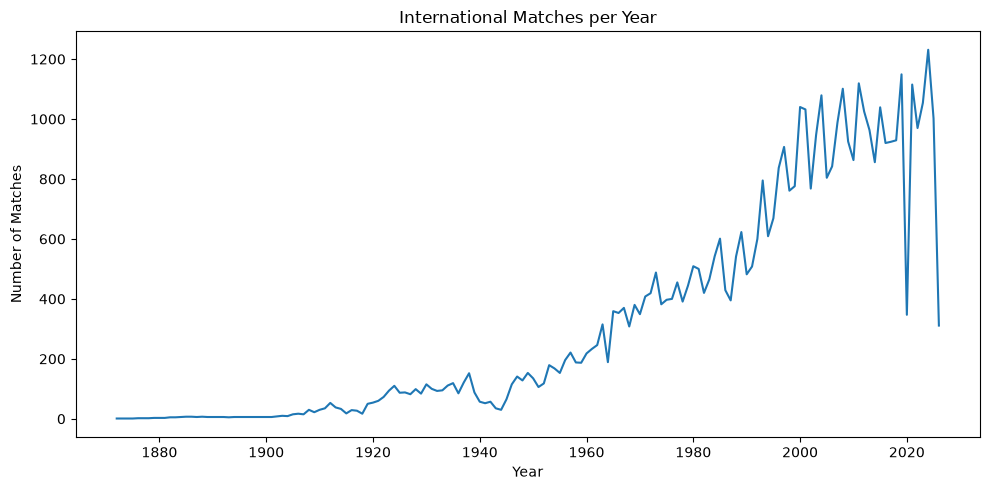

In [5]:
matches_per_year = data.groupby("year").size()

plt.figure(figsize = (10, 5))
matches_per_year.plot(kind = "line")
plt.title("International Matches per Year")
plt.xlabel("Year")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "matches_per_year.png", dpi=300)
plt.show()

### Interpretation: Matches per year

International match volume has increased substantially over time. Beyond major disruptions such as the COVID-19 Pandemic, dips vary due to World Cup qualification cycles, continental championships, and the number of international FIFA windows that are scheduled year-by-year.

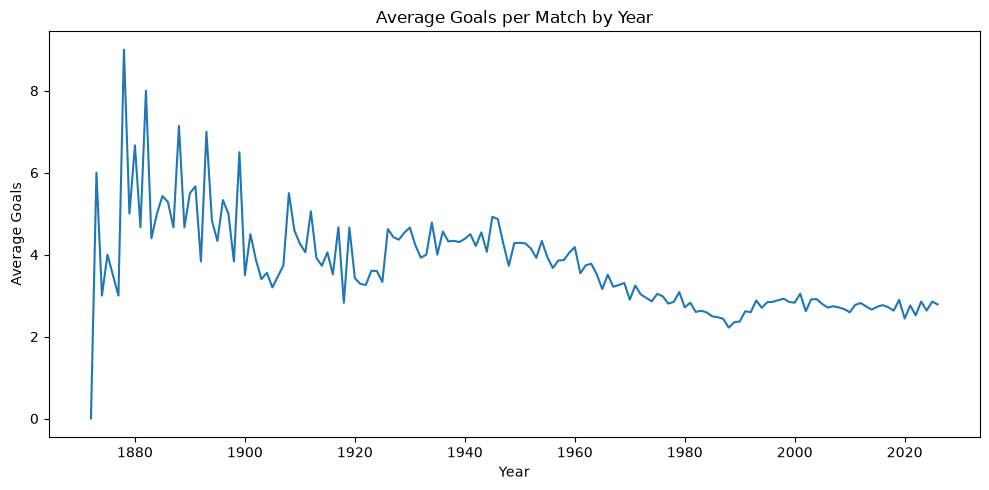

In [6]:
avg_goals_per_year = data.groupby("year")["total_goals"].mean()

plt.figure(figsize = (10, 5))
avg_goals_per_year.plot(kind = "line")
plt.title("Average Goals per Match by Year")
plt.xlabel("Year")
plt.ylabel("Average Goals")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "avg_goals_per_year.png", dpi=300)
plt.show()

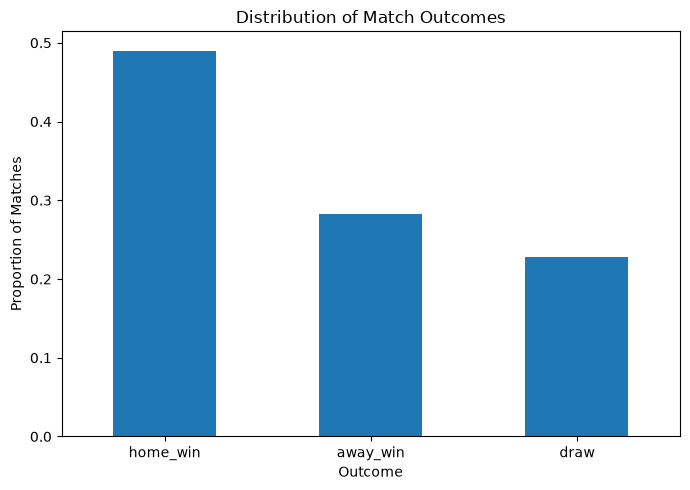

In [8]:
outcome_counts = data["result"].value_counts(normalize=True)

plt.figure(figsize=(7, 5))
outcome_counts.plot(kind="bar")
plt.title("Distribution of Match Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Proportion of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "match_outcome_distribution.png", dpi=300)
plt.show()

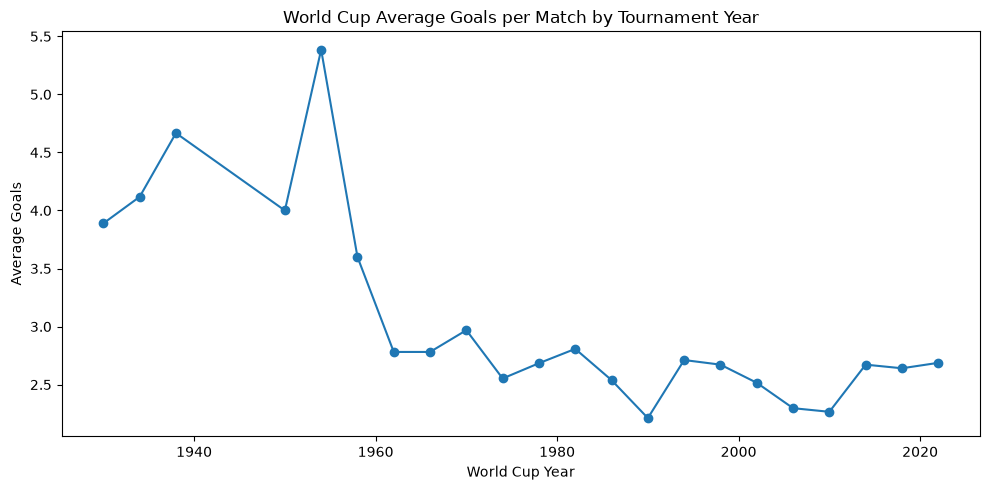

In [9]:
world_cup_data = data[data["is_world_cup"]].copy()

wc_goals_per_year = (
    world_cup_data.groupby("year")["total_goals"].mean()
)

plt.figure(figsize=(10, 5))
wc_goals_per_year.plot(kind="line", marker = "o")
plt.title("World Cup Average Goals per Match by Tournament Year")
plt.xlabel("World Cup Year")
plt.ylabel("Average Goals")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "wc_avg_goals_per_year.png", dpi=300)
plt.show()

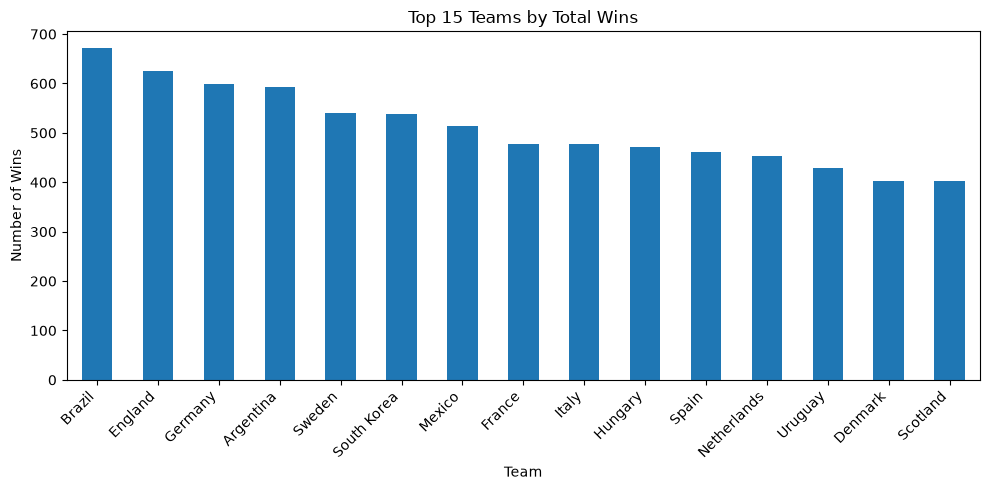

In [ ]:
home_wins = data.loc[data["result"] == "home_win", "home_team"].value_counts()
away_wins = data.loc[data["result"] == "away_win", "away_team"].value_counts()

team_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

top_teams = team_wins.head(15)

plt.figure(figsize=(10, 5))
top_teams.plot(kind="bar")
plt.title("Top 15 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_teams_wins.png", dpi=300)
plt.show()

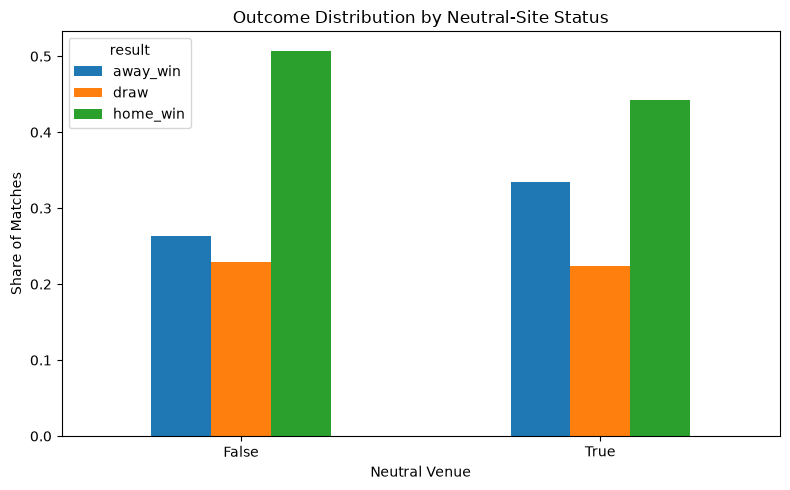

result,away_win,draw,home_win
neutral,,,
False,0.264011,0.228575,0.507415
True,0.334201,0.224001,0.441798


In [ ]:
neutral_outcomes = pd.crosstab(
    data["neutral"],
    data["result"],
    normalize="index"
)

neutral_outcomes.plot(kind="bar", figsize=(8, 5))
plt.title("Outcome Distribution by Neutral-Site Status")
plt.xlabel("Neutral Venue")
plt.ylabel("Share of Matches")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "neutral_site_outcomes.png", dpi=300)
plt.show()

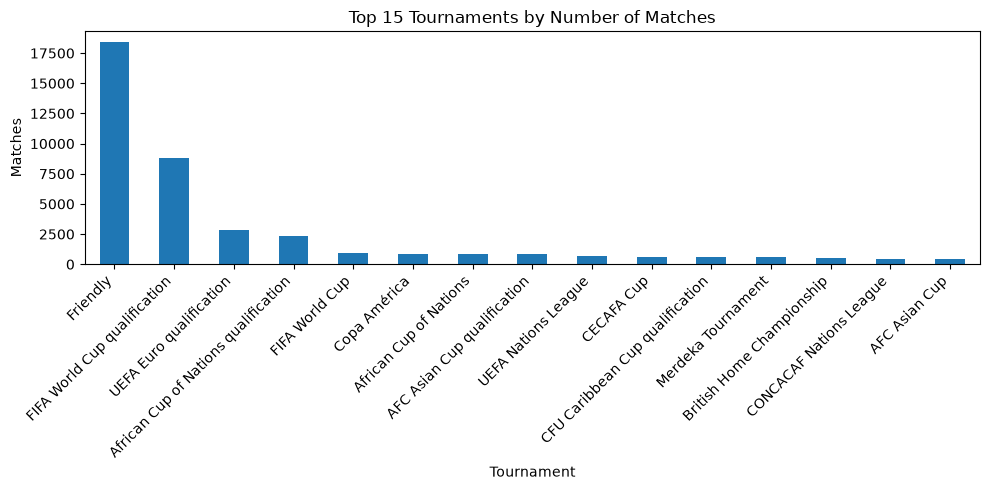

In [ ]:
top_tournaments = data["tournament"].value_counts().head(15)

plt.figure(figsize=(10, 5))
top_tournaments.plot(kind="bar")
plt.title("Top 15 Tournaments by Number of Matches")
plt.xlabel("Tournament")
plt.ylabel("Matches")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "top_tournaments_by_matches.png", dpi=300)
plt.show()